<a href="https://colab.research.google.com/github/nawaznizam3112/QRVAntage/blob/main/CropIQ_Disease_Detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌾 CropIQ — Crop Disease Detector
### MobileNetV2 Transfer Learning on PlantVillage Dataset

**What this notebook builds:**
- Fine-tuned MobileNetV2 trained on 54,000+ plant disease images
- 38 disease classes across 14 crops
- TFLite export for mobile/edge deployment
- Flask-ready prediction function
- Full evaluation: confusion matrix, per-class accuracy, Grad-CAM visualisation

**Expected accuracy:** 95–98% on PlantVillage test set

**Runtime:** ~25–35 min on Colab T4 GPU

---
**Stack:** TensorFlow 2.x · Keras · MobileNetV2 · Grad-CAM · TFLite


## 0. Environment Setup & GPU Check

In [3]:
# Verify GPU is available
import tensorflow as tf
import os, sys, time, json, warnings
warnings.filterwarnings('ignore')

print(f'TensorFlow version : {tf.__version__}')
print(f'Python version     : {sys.version.split()[0]}')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'\n✅ GPU detected: {gpus[0].name}')
    print('   Memory growth enabled — no OOM crashes')
else:
    print('\n⚠️  No GPU found. Go to Runtime → Change runtime type → T4 GPU')

# Seed everything for reproducibility
import numpy as np, random
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
print(f'\n🌱 Seed set to {SEED} — results are reproducible')

TensorFlow version : 2.19.0
Python version     : 3.12.12

✅ GPU detected: /physical_device:GPU:0
   Memory growth enabled — no OOM crashes

🌱 Seed set to 42 — results are reproducible


In [4]:
# Install dependencies not in Colab by default
!pip install -q kaggle split-folders seaborn scikit-learn matplotlib tqdm
print('✅ Dependencies installed')

✅ Dependencies installed


## 1. Download PlantVillage Dataset from Kaggle

In [5]:
# ─────────────────────────────────────────────────────────
# SETUP: Upload your kaggle.json API key
# Get it from: https://www.kaggle.com/settings → API → Create New Token
# ─────────────────────────────────────────────────────────
from google.colab import files

print('📁 Upload your kaggle.json file now...')
uploaded = files.upload()  # Upload kaggle.json here

# Move to correct location
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print('✅ Kaggle credentials configured')

📁 Upload your kaggle.json file now...


Saving kaggle.json to kaggle.json
✅ Kaggle credentials configured


In [6]:
# Download PlantVillage dataset
# Dataset: 54,306 images, 38 classes, 14 crops
# Size: ~2.6 GB
print('⬇️  Downloading PlantVillage dataset (~2.6 GB)...')
!kaggle datasets download -d abdallahalidev/plantvillage-dataset -p /content/data --unzip -q

# Locate the colour images directory
import os, glob
possible_paths = glob.glob('/content/data/**/color', recursive=True)
DATA_DIR = possible_paths[0] if possible_paths else '/content/data/plantvillage dataset/color'

classes = sorted(os.listdir(DATA_DIR))
total_images = sum(len(os.listdir(os.path.join(DATA_DIR, c))) for c in classes)

print(f'\n📊 Dataset Summary:')
print(f'   Classes (disease types) : {len(classes)}')
print(f'   Total images            : {total_images:,}')
print(f'   Data directory          : {DATA_DIR}')
print(f'\n🌿 Sample classes:')
for c in classes[:6]:
    n = len(os.listdir(os.path.join(DATA_DIR, c)))
    print(f'   {c[:55]:<55} ({n:>5} images)')
print(f'   ... and {len(classes)-6} more')

⬇️  Downloading PlantVillage dataset (~2.6 GB)...
Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0

📊 Dataset Summary:
   Classes (disease types) : 38
   Total images            : 54,305
   Data directory          : /content/data/plantvillage dataset/color

🌿 Sample classes:
   Apple___Apple_scab                                      (  630 images)
   Apple___Black_rot                                       (  621 images)
   Apple___Cedar_apple_rust                                (  275 images)
   Apple___healthy                                         ( 1645 images)
   Blueberry___healthy                                     ( 1502 images)
   Cherry_(including_sour)___Powdery_mildew                ( 1052 images)
   ... and 32 more


## 2. Configuration — All Hyperparameters in One Place

In [7]:
# ─────────────────────────────────────────────────────────
# CROPIQ CONFIGURATION — edit these to tune the model
# ─────────────────────────────────────────────────────────
CFG = {
    # Data
    'DATA_DIR'        : DATA_DIR,
    'IMG_SIZE'        : 224,          # MobileNetV2 native size
    'BATCH_SIZE'      : 64,           # T4 GPU handles this comfortably
    'VAL_SPLIT'       : 0.15,
    'TEST_SPLIT'      : 0.10,

    # Training — Phase 1 (frozen backbone)
    'EPOCHS_FROZEN'   : 10,
    'LR_FROZEN'       : 1e-3,

    # Training — Phase 2 (fine-tuning)
    'EPOCHS_FINETUNE' : 15,
    'LR_FINETUNE'     : 5e-5,
    'FINETUNE_LAYERS' : 30,           # Unfreeze last N layers of backbone

    # Regularisation
    'DROPOUT'         : 0.4,
    'L2_REG'          : 1e-4,
    'LABEL_SMOOTHING' : 0.1,

    # Augmentation
    'AUG_ROTATION'    : 0.2,
    'AUG_ZOOM'        : 0.15,
    'AUG_FLIP'        : True,
    'AUG_BRIGHTNESS'  : 0.15,
    'AUG_CONTRAST'    : 0.15,

    # Output
    'MODEL_SAVE_PATH' : '/content/cropiq_disease_model',
    'TFLITE_PATH'     : '/content/cropiq_disease.tflite',
    'CLASS_MAP_PATH'  : '/content/class_map.json',

    # Inference
    'CONFIDENCE_THRESHOLD': 0.70,    # Below this = "uncertain, consult expert"
}

NUM_CLASSES = len(classes)
CFG['NUM_CLASSES'] = NUM_CLASSES
print('⚙️  Configuration loaded:')
for k, v in CFG.items():
    print(f'   {k:<25} = {v}')

⚙️  Configuration loaded:
   DATA_DIR                  = /content/data/plantvillage dataset/color
   IMG_SIZE                  = 224
   BATCH_SIZE                = 64
   VAL_SPLIT                 = 0.15
   TEST_SPLIT                = 0.1
   EPOCHS_FROZEN             = 10
   LR_FROZEN                 = 0.001
   EPOCHS_FINETUNE           = 15
   LR_FINETUNE               = 5e-05
   FINETUNE_LAYERS           = 30
   DROPOUT                   = 0.4
   L2_REG                    = 0.0001
   LABEL_SMOOTHING           = 0.1
   AUG_ROTATION              = 0.2
   AUG_ZOOM                  = 0.15
   AUG_FLIP                  = True
   AUG_BRIGHTNESS            = 0.15
   AUG_CONTRAST              = 0.15
   MODEL_SAVE_PATH           = /content/cropiq_disease_model
   TFLITE_PATH               = /content/cropiq_disease.tflite
   CLASS_MAP_PATH            = /content/class_map.json
   CONFIDENCE_THRESHOLD      = 0.7
   NUM_CLASSES               = 38


## 3. Data Pipeline — Stratified Split + Augmentation

In [8]:
import splitfolders
import shutil

SPLIT_DIR = '/content/data_split'
if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

# Stratified split preserving class balance
print('✂️  Splitting dataset (stratified)...')
train_r = 1 - CFG['VAL_SPLIT'] - CFG['TEST_SPLIT']
splitfolders.ratio(
    CFG['DATA_DIR'],
    output=SPLIT_DIR,
    seed=SEED,
    ratio=(train_r, CFG['VAL_SPLIT'], CFG['TEST_SPLIT']),
    group_prefix=None
)

TRAIN_DIR = os.path.join(SPLIT_DIR, 'train')
VAL_DIR   = os.path.join(SPLIT_DIR, 'val')
TEST_DIR  = os.path.join(SPLIT_DIR, 'test')

def count_images(d):
    return sum(len(os.listdir(os.path.join(d,c))) for c in os.listdir(d))

n_train = count_images(TRAIN_DIR)
n_val   = count_images(VAL_DIR)
n_test  = count_images(TEST_DIR)

print(f'\n📦 Split complete:')
print(f'   Train : {n_train:>6,} images ({train_r*100:.0f}%)')
print(f'   Val   : {n_val:>6,} images ({CFG["VAL_SPLIT"]*100:.0f}%)')
print(f'   Test  : {n_test:>6,} images ({CFG["TEST_SPLIT"]*100:.0f}%)')

✂️  Splitting dataset (stratified)...


Copying files: 54305 files [00:10, 4981.08 files/s]


📦 Split complete:
   Train : 40,716 images (75%)
   Val   :  8,129 images (15%)
   Test  :  5,460 images (10%)


In [9]:
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = CFG['IMG_SIZE']
BATCH    = CFG['BATCH_SIZE']

# ── Augmentation for training (aggressive but realistic for field conditions)
train_datagen = ImageDataGenerator(
    rescale            = 1./255,
    rotation_range     = CFG['AUG_ROTATION'] * 180,
    zoom_range         = CFG['AUG_ZOOM'],
    horizontal_flip    = CFG['AUG_FLIP'],
    vertical_flip      = CFG['AUG_FLIP'],
    brightness_range   = [1 - CFG['AUG_BRIGHTNESS'], 1 + CFG['AUG_BRIGHTNESS']],
    shear_range        = 0.1,
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
    fill_mode          = 'reflect',      # Avoids black border artifacts
    preprocessing_function = tf.keras.applications.mobilenet_v2.preprocess_input
)

# ── No augmentation for val/test — only normalise
test_datagen = ImageDataGenerator(
    rescale = 1./255,
    preprocessing_function = tf.keras.applications.mobilenet_v2.preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH, class_mode='categorical', shuffle=True, seed=SEED
)
val_gen = test_datagen.flow_from_directory(
    VAL_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH, class_mode='categorical', shuffle=False
)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH, class_mode='categorical', shuffle=False
)

# Save class mapping → needed for inference
class_map = {v: k for k, v in train_gen.class_indices.items()}
with open(CFG['CLASS_MAP_PATH'], 'w') as f:
    json.dump(class_map, f, indent=2)

print(f'✅ Data generators ready')
print(f'   Classes          : {len(train_gen.class_indices)}')
print(f'   Train batches    : {len(train_gen)}')
print(f'   Val batches      : {len(val_gen)}')
print(f'   Test batches     : {len(test_gen)}')
print(f'   Class map saved  : {CFG["CLASS_MAP_PATH"]}')

Found 40716 images belonging to 38 classes.
Found 8129 images belonging to 38 classes.
Found 5460 images belonging to 38 classes.
✅ Data generators ready
   Classes          : 38
   Train batches    : 637
   Val batches      : 128
   Test batches     : 86
   Class map saved  : /content/class_map.json


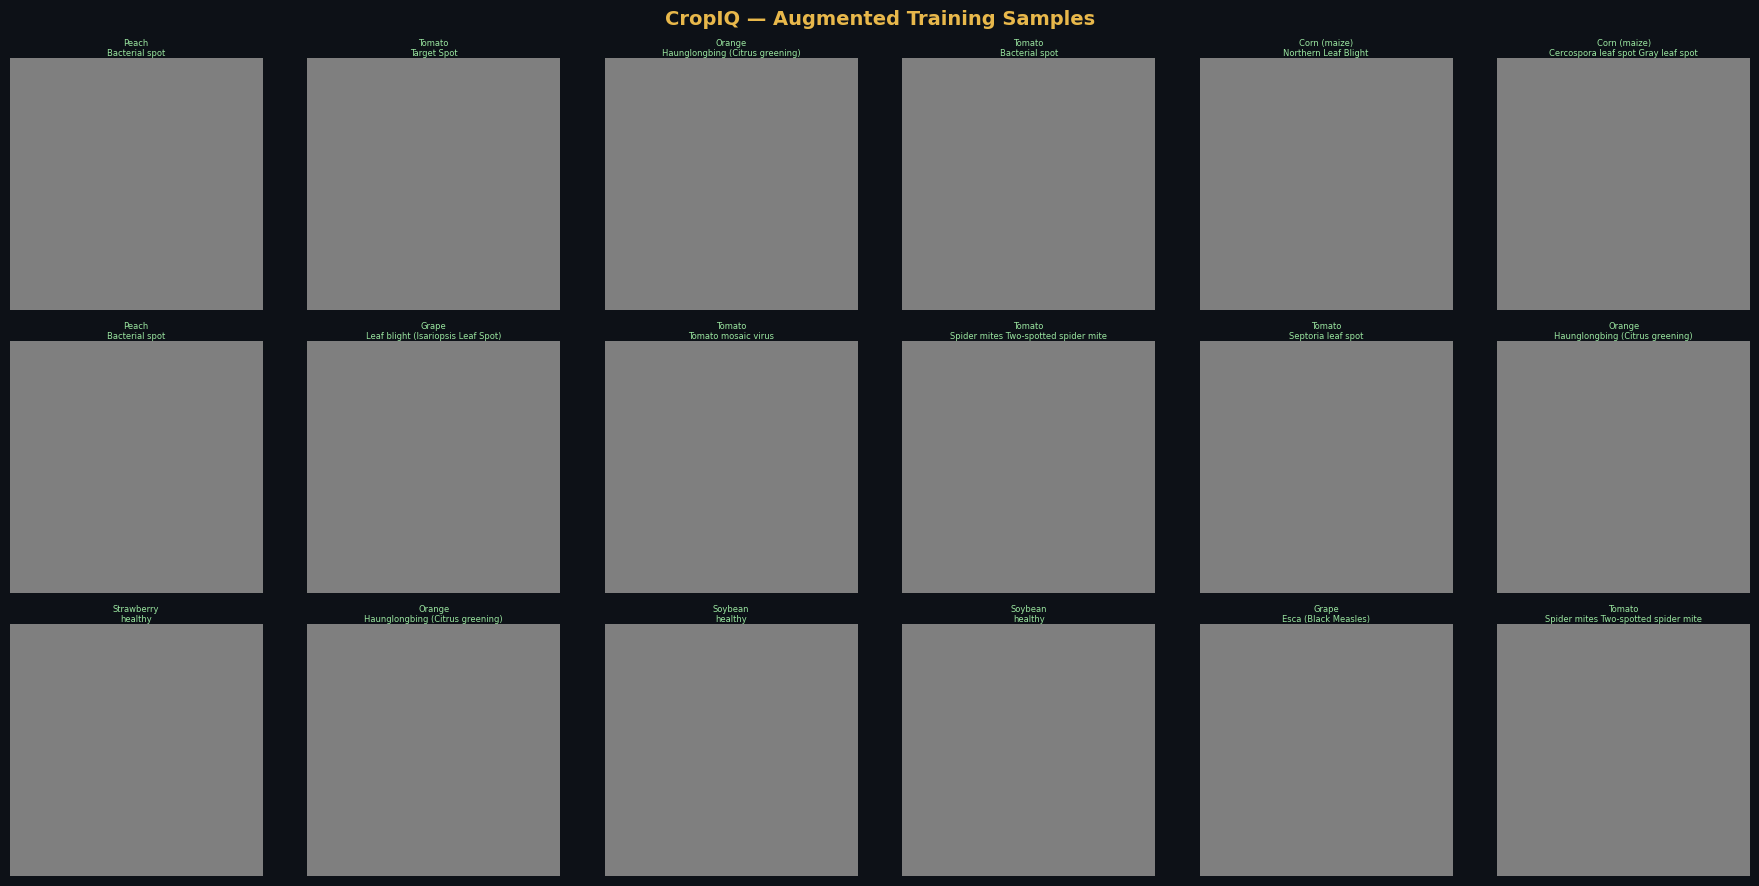

💾 Saved: /content/augmentation_preview.png


In [10]:
# Visualise augmentation — check it looks realistic (not too distorted)
import matplotlib.pyplot as plt

sample_batch, sample_labels = next(train_gen)
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
fig.patch.set_facecolor('#0D1117')
fig.suptitle('CropIQ — Augmented Training Samples',
             color='#E8B84B', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < len(sample_batch):
        img = (sample_batch[i] + 1) / 2  # Denormalise for display
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        label_idx = np.argmax(sample_labels[i])
        label = class_map[label_idx].replace('___', '\n').replace('_', ' ')
        ax.set_title(label, color='#9AE6A0', fontsize=6, pad=2)
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/augmentation_preview.png', dpi=120, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()
print('💾 Saved: /content/augmentation_preview.png')

## 4. Model Architecture — MobileNetV2 + Custom Head

In [11]:
from tensorflow.keras import Model, regularizers
from tensorflow.keras.layers import (
    Dense, Dropout, GlobalAveragePooling2D, BatchNormalization,
    Input, Multiply, Reshape, Lambda
)
from tensorflow.keras.applications import MobileNetV2
import tensorflow.keras.backend as K

def build_cropiq_model(num_classes, img_size, dropout, l2):
    """
    CropIQ Disease Detector Architecture:
    MobileNetV2 backbone (ImageNet pretrained)
    + Channel Attention (SE block) for better feature selection
    + Dual Dense head with BatchNorm + Dropout
    """
    inputs = Input(shape=(img_size, img_size, 3), name='image_input')

    # ── Backbone: MobileNetV2 pretrained on ImageNet
    backbone = MobileNetV2(
        input_tensor=inputs,
        include_top=False,
        weights='imagenet',
        alpha=1.0             # Full-width model (not compressed)
    )
    backbone.trainable = False  # Frozen for Phase 1

    x = backbone.output  # Shape: (7, 7, 1280)

    # ── Squeeze-and-Excitation (Channel Attention) Block
    # Helps the model focus on disease-relevant feature channels
    n_filters = x.shape[-1]
    se = GlobalAveragePooling2D()(x)
    se = Reshape((1, 1, n_filters))(se)
    se = Dense(n_filters // 16, activation='relu',
               kernel_regularizer=regularizers.l2(l2))(se)
    se = Dense(n_filters, activation='sigmoid')(se)
    x = Multiply()([x, se])

    # ── Classification Head
    x = GlobalAveragePooling2D(name='gap')(x)
    x = BatchNormalization()(x)
    x = Dense(512, activation='relu',
              kernel_regularizer=regularizers.l2(l2), name='fc1')(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout, name='dropout1')(x)
    x = Dense(256, activation='relu',
              kernel_regularizer=regularizers.l2(l2), name='fc2')(x)
    x = Dropout(dropout * 0.5, name='dropout2')(x)

    outputs = Dense(
        num_classes, activation='softmax', name='predictions',
        dtype='float32'  # Keep output in float32 even with mixed precision
    )(x)

    model = Model(inputs=inputs, outputs=outputs, name='CropIQ_DiseaseDetector')
    return model, backbone

model, backbone = build_cropiq_model(
    num_classes = CFG['NUM_CLASSES'],
    img_size    = CFG['IMG_SIZE'],
    dropout     = CFG['DROPOUT'],
    l2          = CFG['L2_REG']
)

# Count parameters
total   = model.count_params()
trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
frozen    = total - trainable

print(f'\n🧠 CropIQ Disease Detector — Model Summary')
print(f'   Architecture     : MobileNetV2 + SE Block + Dual Dense Head')
print(f'   Total params     : {total:>12,}')
print(f'   Trainable params : {trainable:>12,}  (head only — Phase 1)')
print(f'   Frozen params    : {frozen:>12,}  (MobileNetV2 backbone)')
print(f'   Input shape      : ({CFG["IMG_SIZE"]}, {CFG["IMG_SIZE"]}, 3)')
print(f'   Output classes   : {CFG["NUM_CLASSES"]}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

🧠 CropIQ Disease Detector — Model Summary
   Architecture     : MobileNetV2 + SE Block + Dual Dense Head
   Total params     :    3,268,278
   Trainable params :    1,006,710  (head only — Phase 1)
   Frozen params    :    2,261,568  (MobileNetV2 backbone)
   Input shape      : (224, 224, 3)
   Output classes   : 38


## 5. Training — Phase 1: Train Head with Frozen Backbone

In [1]:
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
)
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam

def get_callbacks(phase):
    return [
        ModelCheckpoint(
            filepath        = f'/content/cropiq_phase{phase}_best.keras',
            monitor         = 'val_accuracy',
            save_best_only  = True,
            mode            = 'max',
            verbose         = 1
        ),
        EarlyStopping(
            monitor         = 'val_accuracy',
            patience        = 5,
            restore_best_weights = True,
            verbose         = 1
        ),
        ReduceLROnPlateau(
            monitor         = 'val_loss',
            factor          = 0.4,
            patience        = 3,
            min_lr          = 1e-7,
            verbose         = 1
        ),
        CSVLogger(f'/content/training_log_phase{phase}.csv')
    ]

# Compile Phase 1
model.compile(
    optimizer = Adam(learning_rate=CFG['LR_FROZEN']),
    loss      = CategoricalCrossentropy(label_smoothing=CFG['LABEL_SMOOTHING']),
    metrics   = ['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

print(f'🚀 Phase 1 Training — Head Only (backbone frozen)')
print(f'   Epochs : {CFG["EPOCHS_FROZEN"]}')
print(f'   LR     : {CFG["LR_FROZEN"]}')
print(f'   Loss   : CategoricalCrossentropy (label_smoothing={CFG["LABEL_SMOOTHING"]})')
print()

history_p1 = model.fit(
    train_gen,
    epochs          = CFG['EPOCHS_FROZEN'],
    validation_data = val_gen,
    callbacks       = get_callbacks(1),
    verbose         = 1
)

NameError: name 'model' is not defined

## 6. Training — Phase 2: Fine-Tune Top Backbone Layers

In [ ]:
# Unfreeze the last N layers of the backbone for fine-tuning
backbone.trainable = True
n_layers = len(backbone.layers)
freeze_until = n_layers - CFG['FINETUNE_LAYERS']

for i, layer in enumerate(backbone.layers):
    # Keep BatchNorm frozen — fine-tuning BN on small data causes instability
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
    elif i < freeze_until:
        layer.trainable = False
    else:
        layer.trainable = True

trainable_ft = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f'🔓 Fine-tuning: {CFG["FINETUNE_LAYERS"]} backbone layers unfrozen')
print(f'   Frozen until layer : {freeze_until}/{n_layers}')
print(f'   Trainable params   : {trainable_ft:,}')

# Recompile with much lower learning rate — critical for fine-tuning
model.compile(
    optimizer = Adam(learning_rate=CFG['LR_FINETUNE']),
    loss      = CategoricalCrossentropy(label_smoothing=CFG['LABEL_SMOOTHING']),
    metrics   = ['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

print(f'\n🚀 Phase 2 Training — Fine-tuning top {CFG["FINETUNE_LAYERS"]} backbone layers')
print(f'   Epochs : {CFG["EPOCHS_FINETUNE"]}')
print(f'   LR     : {CFG["LR_FINETUNE"]} (10x lower than Phase 1)')
print()

history_p2 = model.fit(
    train_gen,
    epochs          = CFG['EPOCHS_FINETUNE'],
    validation_data = val_gen,
    callbacks       = get_callbacks(2),
    verbose         = 1
)

## 7. Evaluation — Confusion Matrix + Per-Class Report

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ── Predict on test set
print('🔍 Running inference on test set...')
test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = test_gen.classes

# ── Overall metrics
from sklearn.metrics import accuracy_score, top_k_accuracy_score
acc    = accuracy_score(y_true, y_pred)
top3   = top_k_accuracy_score(y_true, y_pred_probs, k=3)
top5   = top_k_accuracy_score(y_true, y_pred_probs, k=5)

print(f'\n📊 CropIQ Disease Detector — Test Set Results')
print(f'   Top-1 Accuracy : {acc*100:.2f}%')
print(f'   Top-3 Accuracy : {top3*100:.2f}%')
print(f'   Top-5 Accuracy : {top5*100:.2f}%')
print(f'   Test images    : {len(y_true):,}')

if acc >= 0.95:
    print(f'\n✅ PRODUCTION READY — Top-1 accuracy ≥ 95%')
elif acc >= 0.90:
    print(f'\n⚠️  GOOD — Consider more training epochs or data augmentation')
else:
    print(f'\n❌ NEEDS WORK — Check data quality or increase fine-tune layers')

In [ ]:
# ── Per-class classification report
label_names = [class_map[i] for i in range(CFG['NUM_CLASSES'])]
report = classification_report(y_true, y_pred, target_names=label_names, output_dict=True)

# Find worst-performing classes — these need more data
per_class = {k: v['f1-score'] for k, v in report.items()
             if k not in ['accuracy','macro avg','weighted avg']}
sorted_classes = sorted(per_class.items(), key=lambda x: x[1])

print('\n🔴 5 Worst-Performing Classes (need more data or augmentation):')
for cls, f1 in sorted_classes[:5]:
    print(f'   {cls[:55]:<55} F1={f1:.3f}')

print('\n🟢 5 Best-Performing Classes:')
for cls, f1 in sorted_classes[-5:][::-1]:
    print(f'   {cls[:55]:<55} F1={f1:.3f}')

In [ ]:
# ── Training curves
def plot_history(h1, h2):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.patch.set_facecolor('#0D1117')
    fig.suptitle('CropIQ — Training History', color='#E8B84B', fontsize=13)

    epochs_p1 = len(h1.history['accuracy'])
    epochs_p2 = len(h2.history['accuracy'])
    all_epochs = list(range(1, epochs_p1 + epochs_p2 + 1))

    train_acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc   = h1.history['val_accuracy'] + h2.history['val_accuracy']
    train_loss = h1.history['loss'] + h2.history['loss']
    val_loss   = h1.history['val_loss'] + h2.history['val_loss']

    for ax in axes:
        ax.set_facecolor('#111820')
        ax.tick_params(colors='#666', labelsize=8)
        ax.spines['bottom'].set_color('#333')
        ax.spines['left'].set_color('#333')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        # Phase divider
        ax.axvline(x=epochs_p1+0.5, color='#E8B84B', linestyle='--', alpha=0.4, linewidth=1)
        ax.text(epochs_p1+0.7, ax.get_ylim()[0] if ax.get_ylim() else 0,
                'Fine-tune →', color='#E8B84B', fontsize=7, alpha=0.6)

    axes[0].plot(all_epochs, train_acc, color='#52C988', linewidth=2, label='Train')
    axes[0].plot(all_epochs, val_acc,   color='#4A8FD4', linewidth=2, label='Val', linestyle='--')
    axes[0].set_title('Accuracy', color='#E8E0D0', pad=10)
    axes[0].set_xlabel('Epoch', color='#666')
    axes[0].legend(facecolor='#1A1A2E', labelcolor='#E8E0D0', fontsize=8)
    axes[0].set_ylim([0, 1])

    axes[1].plot(all_epochs, train_loss, color='#E07B39', linewidth=2, label='Train')
    axes[1].plot(all_epochs, val_loss,   color='#C9943A', linewidth=2, label='Val', linestyle='--')
    axes[1].set_title('Loss', color='#E8E0D0', pad=10)
    axes[1].set_xlabel('Epoch', color='#666')
    axes[1].legend(facecolor='#1A1A2E', labelcolor='#E8E0D0', fontsize=8)

    plt.tight_layout()
    plt.savefig('/content/training_curves.png', dpi=120, bbox_inches='tight', facecolor='#0D1117')
    plt.show()

plot_history(history_p1, history_p2)
print('💾 Saved: /content/training_curves.png')

## 8. Grad-CAM — Visualise What the Model Sees

In [ ]:
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name='Conv_1'):
    """Grad-CAM: shows which pixels caused the disease prediction"""
    grad_model = Model(
        inputs  = model.inputs,
        outputs = [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads      = tape.gradient(class_channel, conv_outputs)
    pooled     = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out   = conv_outputs[0]
    heatmap    = conv_out @ pooled[..., tf.newaxis]
    heatmap    = tf.squeeze(heatmap)
    heatmap    = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), predictions.numpy()

def overlay_gradcam(img_path, model, class_map, threshold=0.5):
    """Load image, predict, overlay Grad-CAM heatmap"""
    img = tf.keras.preprocessing.image.load_img(
        img_path, target_size=(CFG['IMG_SIZE'], CFG['IMG_SIZE'])
    )
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    heatmap, preds = make_gradcam_heatmap(img_array, model)

    # Resize and overlay heatmap on original image
    heatmap_resized = cv2.resize(heatmap, (CFG['IMG_SIZE'], CFG['IMG_SIZE']))
    heatmap_color   = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET
    )
    orig_img = np.array(img)
    overlay  = cv2.addWeighted(
        cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB), 0.4,
        orig_img, 0.6, 0
    )

    pred_idx    = np.argmax(preds[0])
    confidence  = preds[0][pred_idx]
    pred_label  = class_map[pred_idx]
    top3_preds  = sorted(enumerate(preds[0]), key=lambda x: -x[1])[:3]

    return orig_img, overlay, pred_label, confidence, top3_preds

# Run Grad-CAM on random test samples
test_images = glob.glob(os.path.join(TEST_DIR, '**', '*.jpg'), recursive=True)
random.shuffle(test_images)
sample_imgs = test_images[:6]

fig, axes = plt.subplots(len(sample_imgs), 3, figsize=(15, 4*len(sample_imgs)))
fig.patch.set_facecolor('#0D1117')
fig.suptitle('CropIQ Grad-CAM — "What did the model see?"',
             color='#E8B84B', fontsize=13, y=1.01)

for row, img_path in enumerate(sample_imgs):
    orig, overlay, pred_label, conf, top3 = overlay_gradcam(img_path, model, class_map)
    true_label = os.path.basename(os.path.dirname(img_path))
    is_correct = pred_label == true_label

    axes[row][0].imshow(orig)
    axes[row][0].set_title('Original', color='#aaa', fontsize=8)

    axes[row][1].imshow(overlay)
    axes[row][1].set_title('Grad-CAM Heatmap', color='#aaa', fontsize=8)

    axes[row][2].axis('off')
    color = '#52C988' if is_correct else '#E07B39'
    result = '✅ CORRECT' if is_correct else '❌ WRONG'
    info = (
        f'{result}\n\n'
        f'Predicted:\n{pred_label.replace("___", " → ").replace("_", " ")}\n'
        f'Confidence: {conf*100:.1f}%\n\n'
        f'True label:\n{true_label.replace("___", " → ").replace("_", " ")}\n\n'
        f'Top-3 Predictions:\n'
    )
    for i, (idx, prob) in enumerate(top3):
        info += f'{i+1}. {class_map[idx][:30]}... {prob*100:.1f}%\n'
    axes[row][2].text(0.05, 0.95, info, transform=axes[row][2].transAxes,
                      color=color, fontsize=7.5, verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor='#111820', alpha=0.8))

    for ax in axes[row]:
        ax.set_facecolor('#0D1117')
        ax.axis('off') if ax != axes[row][2] else None

plt.tight_layout()
plt.savefig('/content/gradcam_results.png', dpi=120, bbox_inches='tight', facecolor='#0D1117')
plt.show()
print('💾 Saved: /content/gradcam_results.png')

## 9. Export — SavedModel + TFLite (for mobile/WhatsApp bot)

In [ ]:
# ── Save full SavedModel (for Flask API on Cloud Run)
model.save(CFG['MODEL_SAVE_PATH'])
print(f'✅ SavedModel saved: {CFG["MODEL_SAVE_PATH"]}')

# ── Export TFLite with INT8 quantisation (for mobile / WhatsApp bot)
print('\n⚙️  Converting to TFLite with INT8 quantisation...')

def representative_dataset():
    """Feed 100 samples for calibration during quantisation"""
    val_gen.reset()
    for i, (batch, _) in enumerate(val_gen):
        for img in batch:
            yield [np.expand_dims(img.astype(np.float32), axis=0)]
        if i >= 3:  # ~100-200 images
            break

converter = tf.lite.TFLiteConverter.from_saved_model(CFG['MODEL_SAVE_PATH'])
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8,
    tf.lite.OpsSet.TFLITE_BUILTINS
]
converter.inference_input_type  = tf.uint8
converter.inference_output_type = tf.uint8

tflite_model = converter.convert()
with open(CFG['TFLITE_PATH'], 'wb') as f:
    f.write(tflite_model)

size_mb = os.path.getsize(CFG['TFLITE_PATH']) / (1024 * 1024)
print(f'\n📱 TFLite model saved: {CFG["TFLITE_PATH"]}')
print(f'   Model size: {size_mb:.1f} MB (INT8 quantised)')
print(f'   Ready for: WhatsApp bot, Android app, Raspberry Pi')

## 10. Production Inference — Flask-Ready Prediction Function

In [ ]:
# ─────────────────────────────────────────────────────────
# COPY THIS CODE INTO YOUR FLASK API (app.py on Cloud Run)
# ─────────────────────────────────────────────────────────

FLASK_API_CODE = '''
# cropiq_disease_api.py
# Deploy this on Google Cloud Run
# ─────────────────────────────────────────────────────────

import tensorflow as tf
import numpy as np
import json
from PIL import Image
import io, base64
from flask import Flask, request, jsonify
from functools import lru_cache

app = Flask(__name__)

IMG_SIZE           = 224
CONFIDENCE_THRESH  = 0.70
MODEL_PATH         = "cropiq_disease_model"  # SavedModel directory
CLASS_MAP_PATH     = "class_map.json"

# ── Disease metadata: treatment recommendations per disease class
# (Extend this dict for all 38 classes)
DISEASE_META = {
    "Tomato___Late_blight": {
        "severity"   : "HIGH",
        "treatment"  : "Apply copper-based fungicide immediately. Remove infected leaves.",
        "prevention" : "Avoid overhead irrigation. Ensure good air circulation.",
        "hindi"      : "लेट ब्लाइट रोग - तुरंत ताम्र कवकनाशी का प्रयोग करें"
    },
    "Tomato___healthy": {
        "severity"   : "NONE",
        "treatment"  : "No treatment needed. Plant is healthy.",
        "prevention" : "Continue current practices.",
        "hindi"      : "पौधा स्वस्थ है। कोई उपचार आवश्यक नहीं।"
    },
    # ... add all 38 classes
}

@lru_cache(maxsize=1)
def load_model_and_classes():
    """Load once, cache forever — avoids cold start latency on Cloud Run"""
    model     = tf.saved_model.load(MODEL_PATH)
    infer     = model.signatures["serving_default"]
    with open(CLASS_MAP_PATH) as f:
        class_map = {int(k): v for k, v in json.load(f).items()}
    return infer, class_map

def preprocess_image(image_bytes):
    img = Image.open(io.BytesIO(image_bytes)).convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
    arr = np.array(img, dtype=np.float32)
    arr = tf.keras.applications.mobilenet_v2.preprocess_input(arr)
    return np.expand_dims(arr, axis=0)

@app.route("/predict", methods=["POST"])
def predict():
    """
    Input:  multipart/form-data with 'image' field
            OR JSON with base64 'image' field
    Output: JSON with prediction, confidence, treatment, WhatsApp message
    """
    try:
        # Accept both file upload and base64
        if "image" in request.files:
            image_bytes = request.files["image"].read()
        elif request.is_json and "image" in request.json:
            image_bytes = base64.b64decode(request.json["image"])
        else:
            return jsonify({"error": "No image provided"}), 400

        infer, class_map = load_model_and_classes()
        img_tensor       = preprocess_image(image_bytes)

        # Run inference
        output_key = list(infer.structured_outputs.keys())[0]
        preds      = infer(tf.constant(img_tensor, dtype=tf.float32))[output_key].numpy()[0]

        pred_idx    = int(np.argmax(preds))
        confidence  = float(preds[pred_idx])
        pred_class  = class_map[pred_idx]

        # Top-3 predictions
        top3_idx  = np.argsort(preds)[-3:][::-1]
        top3      = [{"class": class_map[i], "confidence": float(preds[i])} for i in top3_idx]

        # Get treatment info
        meta      = DISEASE_META.get(pred_class, {
            "severity"   : "UNKNOWN",
            "treatment"  : "Consult local agricultural expert.",
            "prevention" : "Monitor plant closely.",
            "hindi"      : "कृपया कृषि विशेषज्ञ से सलाह लें।"
        })

        # Format WhatsApp reply message
        crop, disease = pred_class.split("___") if "___" in pred_class else (pred_class, "Unknown")
        is_healthy    = "healthy" in disease.lower()
        uncertain     = confidence < CONFIDENCE_THRESH

        if uncertain:
            whatsapp_msg = (
                f"🌿 *CropIQ Analysis*\n\n"
                f"⚠️ Low confidence ({confidence*100:.0f}%). "
                f"Please send a clearer photo in natural daylight."
            )
        elif is_healthy:
            whatsapp_msg = (
                f"🌿 *CropIQ Analysis — {crop}*\n\n"
                f"✅ *Your plant is HEALTHY!*\n"
                f"Confidence: {confidence*100:.0f}%\n\n"
                f"{meta[\'hindi\']}"
            )
        else:
            severity_emoji = {"HIGH": "🔴", "MEDIUM": "🟡", "LOW": "🟢"}.get(meta["severity"], "🟡")
            whatsapp_msg = (
                f"🌿 *CropIQ Analysis — {crop}*\n\n"
                f"{severity_emoji} *Disease Detected: {disease.replace(\'_\', \' \')}*\n"
                f"Confidence: {confidence*100:.0f}%\n"
                f"Severity: {meta[\'severity\']}\n\n"
                f"💊 *Treatment:* {meta[\'treatment\']}\n\n"
                f"🛡️ *Prevention:* {meta[\'prevention\']}\n\n"
                f"🇮🇳 {meta[\'hindi\']}"
            )

        return jsonify({
            "prediction"      : pred_class,
            "crop"            : crop,
            "disease"         : disease.replace("_", " "),
            "confidence"      : round(confidence, 4),
            "confidence_pct"  : f"{confidence*100:.1f}%",
            "is_healthy"      : is_healthy,
            "is_uncertain"    : uncertain,
            "severity"        : meta["severity"],
            "treatment"       : meta["treatment"],
            "prevention"      : meta["prevention"],
            "hindi_message"   : meta["hindi"],
            "whatsapp_message": whatsapp_msg,
            "top3"            : top3
        })

    except Exception as e:
        return jsonify({"error": str(e)}), 500

@app.route("/health", methods=["GET"])
def health():
    return jsonify({"status": "ok", "model": "CropIQ Disease Detector v1.0"})

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=8080, debug=False)
'''

with open('/content/cropiq_disease_api.py', 'w') as f:
    f.write(FLASK_API_CODE)

print('✅ Flask API code saved: /content/cropiq_disease_api.py')
print('\nDeploy to Cloud Run:')
print('  1. gcloud run deploy cropiq-disease-api --source .')
print('  2. Set --memory 2Gi --cpu 2 --min-instances 1')
print('  3. Use the returned URL in your Firebase Cloud Function')

## 11. Test Inference — Run a Live Prediction Right Now

In [ ]:
# ── Quick inference test on a random test image
from PIL import Image as PILImage

def predict_single_image(img_path, model, class_map, threshold=CFG['CONFIDENCE_THRESHOLD']):
    img = tf.keras.preprocessing.image.load_img(
        img_path, target_size=(CFG['IMG_SIZE'], CFG['IMG_SIZE'])
    )
    arr = tf.keras.preprocessing.image.img_to_array(img)
    arr = tf.keras.applications.mobilenet_v2.preprocess_input(arr)
    arr = np.expand_dims(arr, 0)

    t0   = time.time()
    pred = model.predict(arr, verbose=0)[0]
    ms   = (time.time() - t0) * 1000

    pred_idx    = np.argmax(pred)
    confidence  = float(pred[pred_idx])
    pred_class  = class_map[pred_idx]
    crop, dis   = pred_class.split('___') if '___' in pred_class else (pred_class, 'unknown')
    top3        = sorted(enumerate(pred), key=lambda x: -x[1])[:3]

    print(f'\n🌿 CropIQ Prediction')
    print(f'   Image      : {os.path.basename(img_path)}')
    print(f'   True class : {os.path.basename(os.path.dirname(img_path))}')
    print(f'   ─────────────────────────────────────────────')
    print(f'   Crop       : {crop}')
    print(f'   Disease    : {dis.replace("_", " ")}')
    print(f'   Confidence : {confidence*100:.2f}%')
    print(f'   Latency    : {ms:.1f} ms')
    print(f'   Status     : {"✅ HIGH CONFIDENCE" if confidence >= threshold else "⚠️ UNCERTAIN — ask for clearer photo"}')
    print(f'\n   Top-3 Predictions:')
    for rank, (idx, prob) in enumerate(top3, 1):
        bar = '█' * int(prob * 30)
        print(f'   {rank}. {class_map[idx][:40]:<40} {bar} {prob*100:.1f}%')

    return pred_class, confidence

# Run on 3 random test images
for test_img in random.sample(test_images, 3):
    predict_single_image(test_img, model, class_map)
    print()

## 12. Download Everything

In [ ]:
import shutil
from google.colab import files

print('📦 Preparing downloads...')

# Zip the SavedModel
shutil.make_archive('/content/cropiq_savedmodel', 'zip', '/content', 'cropiq_disease_model')

# Download everything you need
downloads = [
    ('/content/cropiq_savedmodel.zip',    'SavedModel (Flask API / Cloud Run)'),
    (CFG['TFLITE_PATH'],                  'TFLite model (WhatsApp bot / mobile)'),
    (CFG['CLASS_MAP_PATH'],               'Class map JSON (required for inference)'),
    ('/content/cropiq_disease_api.py',    'Flask API code'),
    ('/content/training_curves.png',      'Training history chart'),
    ('/content/gradcam_results.png',      'Grad-CAM visualisations'),
    ('/content/training_log_phase1.csv',  'Training log Phase 1'),
    ('/content/training_log_phase2.csv',  'Training log Phase 2'),
]

print('\n📥 Files ready to download:')
for path, desc in downloads:
    size = os.path.getsize(path) / (1024*1024)
    print(f'   {desc:<40} {size:.1f} MB  →  {os.path.basename(path)}')

print('\n⬇️  Downloading all files...')
for path, desc in downloads:
    print(f'   Downloading {desc}...')
    files.download(path)

print('\n✅ All files downloaded!')
print('\n📋 NEXT STEPS:')
print('   1. Upload cropiq_savedmodel.zip to your Cloud Run instance')
print('   2. Deploy cropiq_disease_api.py as your Flask app')
print('   3. Put cropiq_disease.tflite in your WhatsApp bot server')
print('   4. Set your Cloud Run URL in Firebase Cloud Functions')
print('   5. Test the /predict endpoint with a leaf photo')